# Lab 1. Relevance Vector Regression
Need to implement:
- You need to implement Relevance Vector Regression
- Apply the method on a synthetic dataset, compare with sklearn's Lasso Regression and Ridge Regression
- Apply the method on sync data with RBF features, visualize "relevance vectors", compare with Support Vector Regression and Lasso Regression
- Write conclusions

In [1]:
import numpy as np
from matplotlib import pyplot as plt


%matplotlib inline
np.random.seed(123)

def l2_error(X, t, w):
    return np.sum((X.dot(w.ravel()) - t) ** 2)

## Implement Relevance Vector Regression

You need to implement four functions:

1. `get_w_sigma(X, t, alpha, beta)`. (X, t) - dataset. (alpha, beta) - RVR hyperparameters. The function returns the parameters of the posterior distribution mu, sigma.
2. `update_alpha_beta(X, t, alpha, beta)`. (X, t) - dataset. (alpha, beta) - RVR hyperparameters. The function does one step of the iterative procedure to update the hyperparameters. (talked about this at the lecture).
3. `fit_rvr(X, t, max_iters)`. (X, t) - dataset. max_iters - maximum number of iterations. The function returns the trained hyperparameters and posterior distribution parameters on the model weights.

4. `get_posterior_predictive(X, w, sigma, alpha, beta)`. X - feature matrix. (w, sigma) - parameters of posterior distribution on weights. (alpha, beta) - RVR hyperparameters. Function calculates the mean and standard deviation of the distribution $p(t | x, (X_{train}, t_{train}), \alpha, \beta)$ for predictions on new points from the matrix X.

We recommend that you pay attention:

1. The results of computationally complex operations such as multiplication of the same matrices need to be cached and reused.
2. $\alpha$-s for irrelevant objects, a value must be assigned `np.inf`, and the corresponding weights and variances must have a value of zero
3. Infinities and zeros from the previous paragraph should be processed correctly, without NaNs and warnings
4. A matrix with infinite elements on the diagonal can be inverted more efficiently (it is enough to invert the submatrix)

In [12]:
def get_w_sigma(X, t, alpha, beta):
    """Calculate the mean and the covariance matrix
       of the posterior distribution"""
    n, d = X.shape
    
    # YOUR CODE GOES HERE
    
    w = np.zeros(d)
    rel[:] = alpha < 1e8
    sigma = np.linalg.inv(beta * XTdotX[rel][:, rel] + np.diag(alpha[rel]))
    w[rel] = beta * sigma.dot(XTdotT[rel])
    
    return w, sigma

def update_alpha_beta(X, t, alpha, beta):
    """Update the hyperperemeters to increase evidence"""

    # YOUR CODE GOES HERE
    
    n, d = X.shape
    w, sigma = get_w_sigma(X, t, alpha, beta)
    gamma = 1 - alpha[rel] * np.diag(sigma)
    alpha[rel] = gamma / (w[rel] ** 2)
    alpha[~rel] = np.inf
    tmp = t - X.dot(w)
    beta = (n - gamma.sum()) / tmp.dot(tmp)

    return alpha, beta


def fit_rvr(X, t, max_iter=10000):
    """Train the Relevance Vector Regression model"""

    # YOUR CODE GOES HERE

    global XTdotX, XTdotT, rel
    alpha, beta = np.ones(X.shape[1]), 1
    XTdotX, XTdotT = X.T.dot(X), X.T.dot(t)
    rel = np.ones(X.shape[1], dtype=bool)
    
    for i in range(max_iter):
        alpha, beta = update_alpha_beta(X, t, alpha, beta)
    
    w, s = get_w_sigma(X, t, alpha, beta)
    sigma = np.zeros_like(XTdotX)
    sigma[rel][:, rel] = s
    
    return w, sigma, alpha, beta

def get_posterior_predictive(X, w, sigma, alpha, beta):
    """" Compute the mean and the standard deviation
         of the posterior predictive distribution for inputs X"""

    # YOUR CODE GOES HERE

    mu = X.dot(w)
    param_uncertainty = (X.dot(sigma) * X).sum(axis=1)
    noise_variance = 1.0 / beta
    
    variance = noise_variance + param_uncertainty
    
    std = np.sqrt(variance)

    return mu, std

## Polynomial recovery

A toy problem is solved: a noisy polynomial of the third degree generates data for the regression problem. It is necessary to train a polynomial of degree not exceeding 20 using this data. It is necessary to compare three models: Ridge Regression, L1-regression (Lasso) and RVR, and compare the error on the test set and the quality of the selected features.

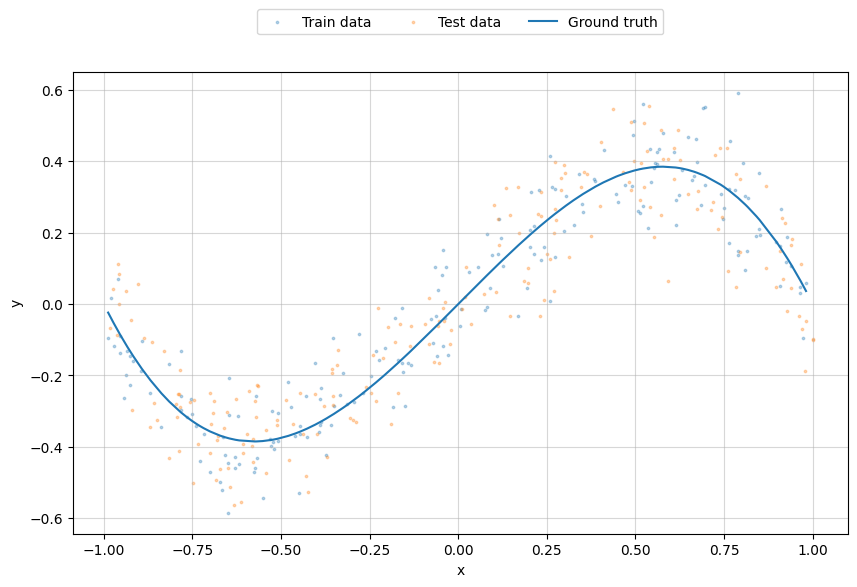

In [13]:
# Data generation

def gen_batch(n, w, beta):
    d = len(w)
    X = np.random.uniform(-1, 1, (n, 1))
    X = np.sort(X, axis=0)
    X = np.hstack([X ** i for i in range(d)])
    t = X.dot(w) + np.random.normal(size=n) / beta ** 0.5
    return X, t

n = 200
d = 21
w_true = np.zeros(d)
w_true[1] = 1
w_true[3] = -1
beta_true = 100

X_train, t_train = gen_batch(n, w_true, beta_true)
X_test, t_test = gen_batch(n, w_true, beta_true)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train[:, 1], t_train, s=3, label='Train data', alpha=0.3)
ax.scatter(X_test[:, 1], t_test, s=3, label='Test data', alpha=0.3)
ax.plot(X_train[:, 1], X_train.dot(w_true), label='Ground truth')

ax.grid(True, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(ncol=3, loc=9, bbox_to_anchor=(0.5, 1.15))
plt.show()

In [14]:
# Relevance Vector Regression
w_rvr, sigma_rvr, alpha_rvr, beta_rvr = fit_rvr(X_train, t_train)

In [15]:
predictive_mu, predictive_std = get_posterior_predictive(
    X_test,
    w_rvr,
    sigma_rvr,
    alpha_rvr,
    beta_rvr)

In [16]:
# Ridge Regression with Cross-Validation
from sklearn.linear_model import RidgeCV
ridge = RidgeCV(cv=20, alphas=10.**np.linspace(-6, 3, 100),
                fit_intercept=False).fit(X_train, t_train)
w_ridge = ridge.coef_

In [17]:
# Lasso Regression with Cross-Validation
from sklearn.linear_model import LassoCV, Lasso
lasso = LassoCV(cv=5, alphas=10.**np.linspace(-6, 3, 100),
                fit_intercept=False, max_iter=2000000).fit(X_train, t_train)
w_lasso = lasso.coef_

Relevance Vector Regression
Features remaining: 4 / 21
Train error: 0.008594964634428364
Test error:  0.011194198997285966
--------------------------------------------------
Ridge Regression
Features remaining: NA (no sparsity)
Train error: 0.008473539314599548
Test error:  0.011278470530813309
--------------------------------------------------
Lasso Regression
Features remaining: 6 / 21
Train error: 0.008504882867973107
Test error:  0.01121386480752521


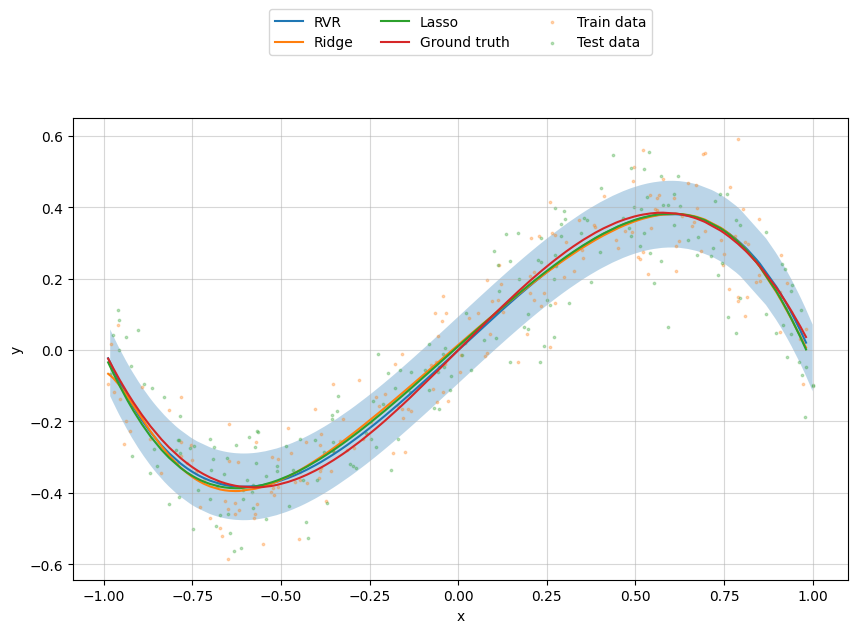

In [18]:
# Comparison
print('Relevance Vector Regression')
print('Features remaining:', np.sum(alpha_rvr < 1e8), '/', d)
print('Train error:', l2_error(X_train, t_train, w_rvr) / n)
print('Test error: ', l2_error(X_test, t_test, w_rvr) / n)
print('-'*50)
print('Ridge Regression')
print('Features remaining: NA (no sparsity)')
print('Train error:', l2_error(X_train, t_train, w_ridge) / n)
print('Test error: ', l2_error(X_test, t_test, w_ridge) / n)
print('-'*50)
print('Lasso Regression')
print('Features remaining:', np.sum(np.abs(w_lasso) > 1e-20), '/', d)
print('Train error:', l2_error(X_train, t_train, w_lasso) / n)
print('Test error: ', l2_error(X_test, t_test, w_lasso) / n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(X_test[:, 1],
                predictive_mu - predictive_std,
                predictive_mu + predictive_std,
                alpha=0.3)
ax.plot(X_train[:, 1], X_train.dot(w_rvr), label='RVR')
ax.plot(X_train[:, 1], X_train.dot(w_ridge), label='Ridge')
ax.plot(X_train[:, 1], X_train.dot(w_lasso), label='Lasso')
ax.plot(X_train[:, 1], X_train.dot(w_true), label='Ground truth')

ax.scatter(X_train[:, 1], t_train, s=3, label='Train data', alpha=0.3)
ax.scatter(X_test[:, 1], t_test, s=3, label='Test data', alpha=0.3)


ax.grid(True, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(ncol=3, loc=9, bbox_to_anchor=(0.5, 1.25))
plt.show()

## Regression with RBF-features

At this point another toy problem is solved: it is necessary to restore the noisy function `sinc(x)`. It is necessary to use a kernel trick with the RBF-kernel (you can use the function `sklearn.metrics.pairwise.rbf_kernel`), train three models: SVM regression (SVR), L1 regression (Lasso) and RVR, and compare the error on the test set and the quality of the selected reference / relevant objects.

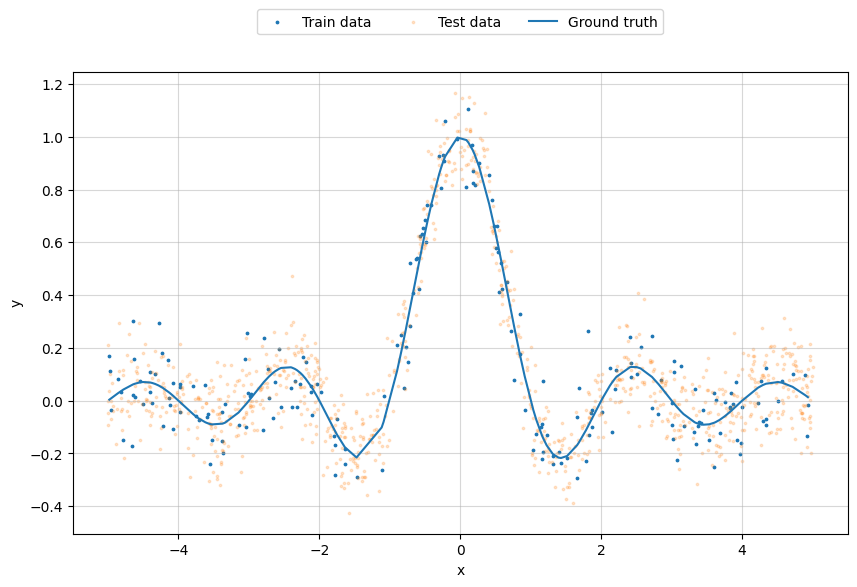

In [23]:
# Data generation
from sklearn.metrics.pairwise import rbf_kernel

def gen_batch(n, beta):
    points = np.random.uniform(-5, 5, n)
    points = np.sort(points)
    t = np.sinc(points) + np.random.normal(size=n) / beta ** 0.5
    return points, t

n = 200
n_test = 1000
d = n + 1
beta_true = 100

points_train, t_train = gen_batch(n, beta_true)
points_test, t_test = gen_batch(n_test, beta_true)

# RBF-transform
X_train = rbf_kernel(points_train[:, np.newaxis])
X_test = rbf_kernel(points_test[:, np.newaxis], points_train[:, np.newaxis])
# Constant feature
X_train = np.hstack((np.ones((n, 1)), X_train))
X_test = np.hstack((np.ones((n_test, 1)), X_test))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(points_train, t_train, s=3, label='Train data', alpha=1)
ax.scatter(points_test, t_test, s=3, label='Test data', alpha=0.2)
ax.plot(points_train, np.sinc(points_train), label='Ground truth')

ax.grid(True, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(ncol=3, loc=9, bbox_to_anchor=(0.5, 1.15))
plt.show()

In [24]:
# Relevance Vector Regression
w_rvr, sigma_rvr, alpha_rvr, beta_rvr = fit_rvr(X_train, t_train)

In [25]:
predictive_mu, predictive_std = get_posterior_predictive(
    X_test,
    w_rvr,
    sigma_rvr,
    alpha_rvr,
    beta_rvr)

In [26]:
# Lasso Regression with Cross-Validation
from sklearn.linear_model import LassoCV
lasso = LassoCV(cv=10, alphas=10.**np.linspace(-5, 1, 20),
                fit_intercept=False, max_iter=100000, tol=1e-2, n_jobs=10).fit(X_train, t_train)
w_lasso = lasso.coef_

In [27]:
# Support Vector Regression
from sklearn.svm import SVR
svr = SVR(gamma=1, tol=1e-6, C=1).fit(points_train.reshape(-1, 1), t_train)

Relevance Vector Regression
Objects remaining: 8 / 200
Train error: 0.010116727780745696
Test error:  0.05675232836958898
--------------------------------------------------
Lasso Regression
Objects remaining: 102 / 200
Train error: 0.009971739140203663
Test error:  0.054726825773752416
--------------------------------------------------
Support Vector Regression
Objects remaining: 74 / 200
Train error: 0.01009607245768568
Test error:  0.05555616642757661


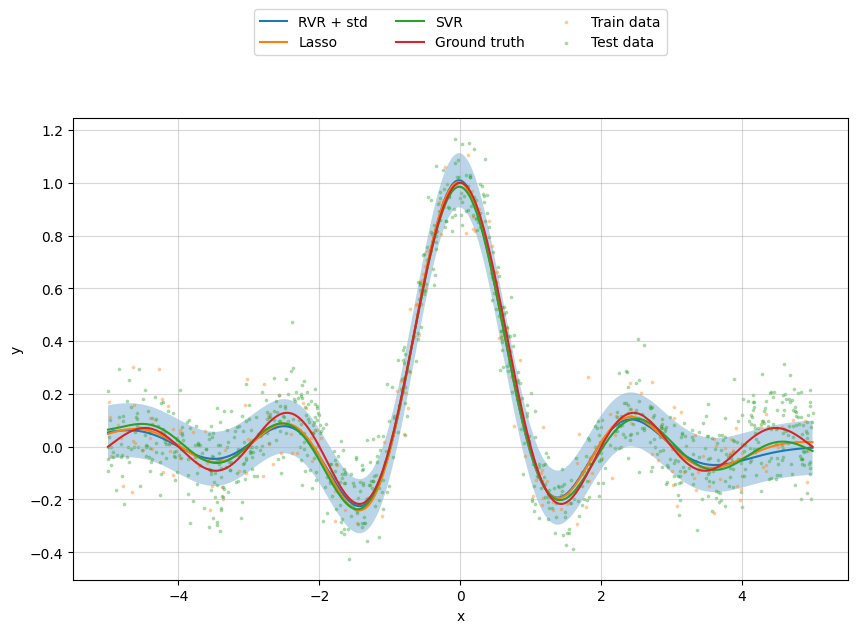

In [28]:
# Comparison
print('Relevance Vector Regression')
print('Objects remaining:', np.sum(alpha_rvr[1:] < 1e8), '/', n)
print('Train error:', l2_error(X_train, t_train, w_rvr) / n)
print('Test error: ', l2_error(X_test, t_test, w_rvr) / n)
print('-'*50)
print('Lasso Regression')
print('Objects remaining:', np.sum(np.abs(w_lasso[1:]) > 1e-20), '/', n)
print('Train error:', l2_error(X_train, t_train, w_lasso) / n)
print('Test error: ', l2_error(X_test, t_test, w_lasso) / n)
print('-'*50)
print('Support Vector Regression')
print('Objects remaining:', len(svr.support_), '/', n)
print('Train error:', np.sum((svr.predict(points_train.reshape(-1, 1)) - t_train) ** 2) / n)
print('Test error: ', np.sum((svr.predict(points_test.reshape(-1, 1)) - t_test) ** 2) / n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(points_test,
                predictive_mu - predictive_std,
                predictive_mu + predictive_std, alpha=0.3)
ax.plot(points_test, X_test.dot(w_rvr), label='RVR + std')
ax.plot(points_test, X_test.dot(w_lasso), label='Lasso')
ax.plot(points_test, svr.predict(points_test.reshape(-1, 1)), label='SVR')
ax.plot(points_test, np.sinc(points_test), label='Ground truth')
ax.scatter(points_train, t_train, s=3, label='Train data', alpha=0.3)
ax.scatter(points_test, t_test, s=3, label='Test data', alpha=0.3)


ax.grid(True, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(ncol=3, loc=9, bbox_to_anchor=(0.5, 1.25))
plt.show()

### Visualization of relevant objects for RVR

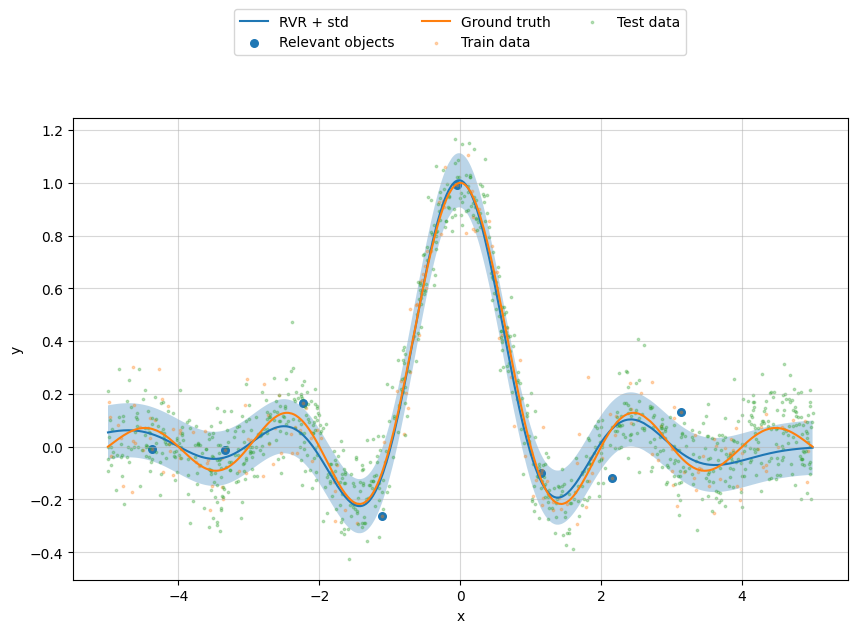

In [29]:
relevant = alpha_rvr[1:] < 1e8
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(points_test,
                predictive_mu - predictive_std,
                predictive_mu + predictive_std, alpha=0.3)
ax.plot(points_test, X_test.dot(w_rvr), label='RVR + std')
ax.scatter(points_train[relevant], t_train[relevant], c='tab:blue', s=30, label='Relevant objects')
ax.plot(points_test, np.sinc(points_test), label='Ground truth')
ax.scatter(points_train, t_train, s=3, label='Train data', alpha=0.3)
ax.scatter(points_test, t_test, s=3, label='Test data', alpha=0.3)

ax.grid(True, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(ncol=3, loc=9, bbox_to_anchor=(0.5, 1.25))
plt.show()

## Conclusion
Here describe your observations and formulate your conclusions

RVR performed better in the first test, approximating the polynomial well and achieving low error on the test data. Lasso and Ridge overfit and used all the features. In the second test, the methods were similar. Ultimately, RVR wins due to its sparse results and lower variance in predictions.